In [1]:
import sys
print(sys.version)

3.13.1 (tags/v3.13.1:0671451, Dec  3 2024, 19:06:28) [MSC v.1942 64 bit (AMD64)]


In [2]:
import pandas as pd
import numpy as np

print("Libraries Imported Successfully ✅")

Libraries Imported Successfully ✅


In [3]:
customers = pd.read_csv(r"..\Data\Raw Data\olist_customers_dataset.csv")
Location = pd.read_csv(r"..\Data\Raw Data\olist_geolocation_dataset.csv")
Order_Items = pd.read_csv(r"..\Data\Raw Data\olist_order_items_dataset.csv")
Order_Payments = pd.read_csv(r"..\Data\Raw Data\olist_order_payments_dataset.csv")
Order_Reviews = pd.read_csv(r"..\Data\Raw Data\olist_order_reviews_dataset.csv")
Orders = pd.read_csv(r"..\Data\Raw Data\olist_orders_dataset.csv")
Products = pd.read_csv(r"..\Data\Raw Data\olist_products_dataset.csv")
Sellers = pd.read_csv(r"..\Data\Raw Data\olist_sellers_dataset.csv")
Product_Category = pd.read_csv(r"..\Data\Raw Data\product_category_name_translation.csv")
print("done")

done


In [4]:
customers.head(3)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


In [5]:
customers.shape


(99441, 5)

In [6]:
Orders.shape


(99441, 8)

In [7]:

Order_Payments.shape

(103886, 5)

In [8]:
Orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [9]:
Orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [10]:
Orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [11]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [12]:
Orders['order_purchase_timestamp'] = pd.to_datetime(Orders['order_purchase_timestamp'])
Orders['order_approved_at'] = pd.to_datetime(Orders['order_approved_at'])
Orders['order_delivered_carrier_date'] = pd.to_datetime(Orders['order_delivered_carrier_date'])
Orders['order_delivered_customer_date'] = pd.to_datetime(Orders['order_delivered_customer_date'])
Orders['order_estimated_delivery_date'] = pd.to_datetime(Orders['order_estimated_delivery_date'])


In [13]:
Orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [14]:
Orders_clean = Orders[Orders['order_status'] == 'delivered']
Orders_clean.shape

(96478, 8)

In [15]:
order_revenue = Order_Payments.groupby('order_id')['payment_value'].sum().reset_index()
order_revenue.head(10)

,order_id,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04
5,00048cc3ae777c65dbb7d2a0634bc1ea,34.59
6,00054e8431b9d7675808bcb819fb4a32,31.75
7,000576fe39319847cbb9d288c5617fa6,880.75
8,0005a1a1728c9d785b8e2b08b904576c,157.60
9,0005f50442cb953dcd1d21e1fb923495,65.39


In [16]:
CLV_base = Orders_clean.merge(order_revenue, on='order_id', how='left')

In [17]:
CLV_base.shape


(96478, 9)

In [18]:
CLV_base.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,28.62


In [19]:
CLV_base.isnull().sum()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
payment_value                     1
dtype: int64

In [20]:
CLV_base['payment_value'] = CLV_base['payment_value'].fillna(0)

CLV_base['payment_value'].isnull().sum()

np.int64(0)

In [21]:
CLV_base.isnull().sum()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
payment_value                     0
dtype: int64

In [22]:
customer_revenue = CLV_base.groupby('customer_id')['payment_value'].sum().reset_index()

customer_revenue.head()

,customer_id,payment_value
0,00012a2ce6f8dcda20d059ce98491703,114.74
1,000161a058600d5901f007fab4c27140,67.41
2,0001fd6190edaaf884bcaf3d49edf079,195.42
3,0002414f95344307404f0ace7a26f1d5,179.35
4,000379cdec625522490c315e70c7a9fb,107.01


In [23]:
customer_frequency = CLV_base.groupby('customer_id')['order_id'].count().reset_index()

customer_frequency.rename(columns={'order_id': 'total_orders'}, inplace=True)

customer_frequency.head()

,customer_id,total_orders
0,00012a2ce6f8dcda20d059ce98491703,1
1,000161a058600d5901f007fab4c27140,1
2,0001fd6190edaaf884bcaf3d49edf079,1
3,0002414f95344307404f0ace7a26f1d5,1
4,000379cdec625522490c315e70c7a9fb,1


In [24]:
customer_clv = customer_revenue.merge(customer_frequency, on='customer_id', how='left')

customer_clv.head()

,customer_id,payment_value,total_orders
0,00012a2ce6f8dcda20d059ce98491703,114.74,1
1,000161a058600d5901f007fab4c27140,67.41,1
2,0001fd6190edaaf884bcaf3d49edf079,195.42,1
3,0002414f95344307404f0ace7a26f1d5,179.35,1
4,000379cdec625522490c315e70c7a9fb,107.01,1


In [25]:
customer_clv.shape

(96478, 3)

In [26]:
customer_dates = CLV_base.groupby('customer_id')['order_purchase_timestamp'].agg(['min','max']).reset_index()

customer_dates.rename(columns={'min':'first_purchase',
                               'max':'last_purchase'}, inplace=True)

customer_dates.head()

,customer_id,first_purchase,last_purchase
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,2017-11-14 16:08:26
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,2017-07-16 09:40:32
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,2017-02-28 11:06:43
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,2017-08-16 13:09:20
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,2018-04-02 13:42:17


In [27]:
customer_clv = customer_clv.merge(customer_dates, on='customer_id', how='left')

customer_clv.head()

,customer_id,payment_value,total_orders,first_purchase,last_purchase
0,00012a2ce6f8dcda20d059ce98491703,114.74,1,2017-11-14 16:08:26,2017-11-14 16:08:26
1,000161a058600d5901f007fab4c27140,67.41,1,2017-07-16 09:40:32,2017-07-16 09:40:32
2,0001fd6190edaaf884bcaf3d49edf079,195.42,1,2017-02-28 11:06:43,2017-02-28 11:06:43
3,0002414f95344307404f0ace7a26f1d5,179.35,1,2017-08-16 13:09:20,2017-08-16 13:09:20
4,000379cdec625522490c315e70c7a9fb,107.01,1,2018-04-02 13:42:17,2018-04-02 13:42:17


In [28]:
customer_clv.shape

(96478, 5)

In [29]:
customer_clv['payment_value'].mean()

np.float64(159.85470024254235)

In [30]:
snapshot_date = CLV_base['order_purchase_timestamp'].max()

snapshot_date

Timestamp('2018-08-29 15:00:37')

In [31]:
recency = CLV_base.groupby('customer_id')['order_purchase_timestamp'].max().reset_index()

recency['recency_days'] = (snapshot_date - recency['order_purchase_timestamp']).dt.days

recency.head()

,customer_id,order_purchase_timestamp,recency_days
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,287
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,409
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,547
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,378
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,149


In [32]:
frequency = CLV_base.groupby('customer_id')['order_id'].count().reset_index()

frequency.rename(columns={'order_id':'frequency'}, inplace=True)

frequency.head()

,customer_id,frequency
0,00012a2ce6f8dcda20d059ce98491703,1
1,000161a058600d5901f007fab4c27140,1
2,0001fd6190edaaf884bcaf3d49edf079,1
3,0002414f95344307404f0ace7a26f1d5,1
4,000379cdec625522490c315e70c7a9fb,1


In [33]:
monetary = CLV_base.groupby('customer_id')['payment_value'].sum().reset_index()

monetary.rename(columns={'payment_value':'monetary_value'}, inplace=True)

monetary.head()

,customer_id,monetary_value
0,00012a2ce6f8dcda20d059ce98491703,114.74
1,000161a058600d5901f007fab4c27140,67.41
2,0001fd6190edaaf884bcaf3d49edf079,195.42
3,0002414f95344307404f0ace7a26f1d5,179.35
4,000379cdec625522490c315e70c7a9fb,107.01


In [34]:
rfm = recency.merge(frequency, on='customer_id')

rfm = rfm.merge(monetary, on='customer_id')

rfm.head()

,customer_id,order_purchase_timestamp,recency_days,frequency,monetary_value
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,287,1,114.74
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,409,1,67.41
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,547,1,195.42
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,378,1,179.35
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,149,1,107.01


In [35]:
rfm['R_score'] = pd.qcut(rfm['recency_days'], 5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['monetary_value'], 5, labels=[1,2,3,4,5])

rfm.head()

,customer_id,order_purchase_timestamp,recency_days,frequency,monetary_value,R_score,F_score,M_score
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,287,1,114.74,2,1,3
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,409,1,67.41,1,1,2
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,547,1,195.42,1,1,4
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,378,1,179.35,2,1,4
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,149,1,107.01,4,1,3


In [36]:
rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

rfm.head()

,customer_id,order_purchase_timestamp,recency_days,frequency,monetary_value,R_score,F_score,M_score,RFM_score
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,287,1,114.74,2,1,3,213
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,409,1,67.41,1,1,2,112
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,547,1,195.42,1,1,4,114
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,378,1,179.35,2,1,4,214
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,149,1,107.01,4,1,3,413


In [37]:
def segment_customer(row):
    if row['R_score'] >= 4 and row['M_score'] >= 4:
        return 'Champions'
    elif row['R_score'] >= 3 and row['F_score'] >= 3:
        return 'Loyal Customers'
    elif row['R_score'] >= 4:
        return 'Potential Customers'
    elif row['R_score'] <= 2 and row['F_score'] <= 2:
        return 'At Risk'
    else:
        return 'Others'

rfm['customer_segment'] = rfm.apply(segment_customer, axis=1)

rfm.head()

,customer_id,order_purchase_timestamp,recency_days,frequency,monetary_value,R_score,F_score,M_score,RFM_score,customer_segment
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,287,1,114.74,2,1,3,213,At Risk
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,409,1,67.41,1,1,2,112,At Risk
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,547,1,195.42,1,1,4,114,At Risk
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,378,1,179.35,2,1,4,214,At Risk
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,149,1,107.01,4,1,3,413,Potential Customers


In [38]:
rfm['customer_segment'].value_counts()

customer_segment
Others                 30927
Loyal Customers        25021
Champions              15989
At Risk                15304
Potential Customers     9237
Name: count, dtype: int64

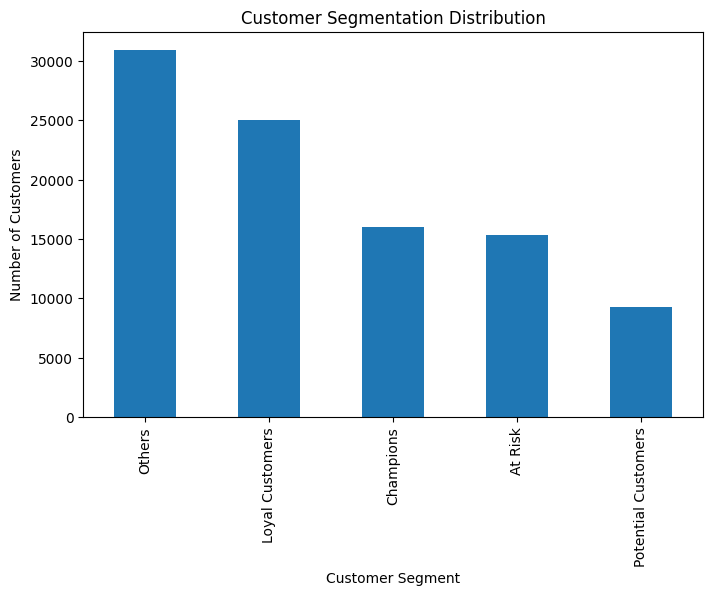

In [39]:
import matplotlib.pyplot as plt

segment_counts = rfm['customer_segment'].value_counts()

plt.figure(figsize=(8,5))
segment_counts.plot(kind='bar')

plt.title('Customer Segmentation Distribution')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')

plt.show()

In [40]:
rfm['avg_order_value'] = rfm['monetary_value'] / rfm['frequency']

rfm.head()

,customer_id,order_purchase_timestamp,recency_days,frequency,monetary_value,R_score,F_score,M_score,RFM_score,customer_segment,avg_order_value
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,287,1,114.74,2,1,3,213,At Risk,114.74
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,409,1,67.41,1,1,2,112,At Risk,67.41
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,547,1,195.42,1,1,4,114,At Risk,195.42
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,378,1,179.35,2,1,4,214,At Risk,179.35
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,149,1,107.01,4,1,3,413,Potential Customers,107.01


In [41]:
purchase_frequency = rfm['frequency'].mean()

purchase_frequency

np.float64(1.0)

In [42]:
customer_lifetime = rfm['recency_days'].mean()

customer_lifetime

np.float64(239.12136445614544)

In [43]:
rfm['CLV'] = rfm['avg_order_value'] * purchase_frequency * customer_lifetime

rfm.head()

,customer_id,order_purchase_timestamp,recency_days,frequency,monetary_value,R_score,F_score,M_score,RFM_score,customer_segment,avg_order_value,CLV
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,287,1,114.74,2,1,3,213,At Risk,114.74,27436.785358
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,409,1,67.41,1,1,2,112,At Risk,67.41,16119.171178
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,547,1,195.42,1,1,4,114,At Risk,195.42,46729.097042
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,378,1,179.35,2,1,4,214,At Risk,179.35,42886.416715
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,149,1,107.01,4,1,3,413,Potential Customers,107.01,25588.377210


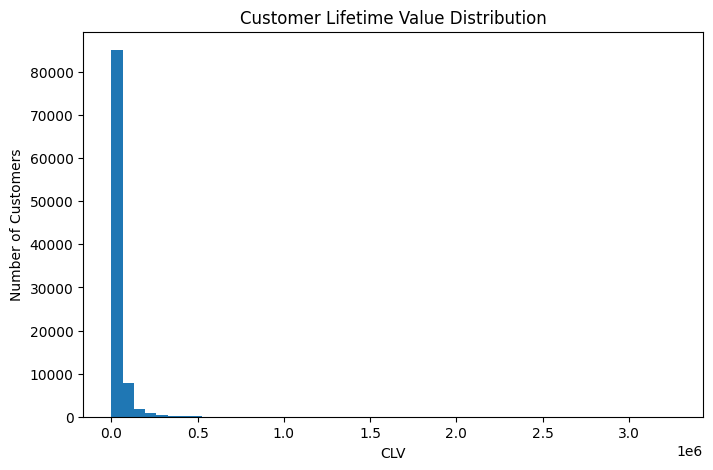

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(rfm['CLV'], bins=50)

plt.title("Customer Lifetime Value Distribution")
plt.xlabel("CLV")
plt.ylabel("Number of Customers")

plt.show()

In [45]:
segment_clv = rfm.groupby('customer_segment')['CLV'].mean()

segment_clv

customer_segment
At Risk                38240.797971
Champions              70542.692125
Loyal Customers        26008.118971
Others                 37715.662964
Potential Customers    17052.546489
Name: CLV, dtype: float64

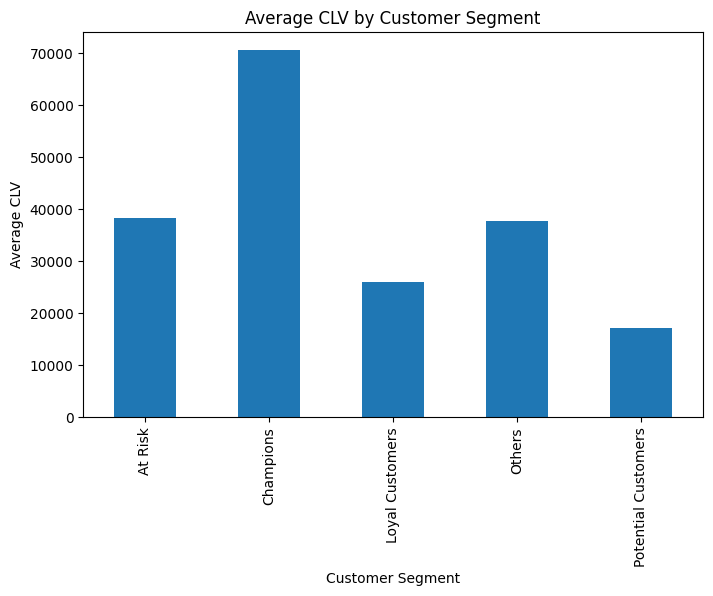

In [46]:
segment_clv.plot(kind='bar', figsize=(8,5))

plt.title("Average CLV by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average CLV")

plt.show()

In [47]:
ml_data = rfm[['recency_days','frequency','monetary_value','CLV']]

ml_data.head()

,recency_days,frequency,monetary_value,CLV
0,287,1,114.74,27436.785358
1,409,1,67.41,16119.171178
2,547,1,195.42,46729.097042
3,378,1,179.35,42886.416715
4,149,1,107.01,25588.377210


In [48]:
from sklearn.model_selection import train_test_split

X = ml_data[['recency_days','frequency','monetary_value']]
y = ml_data['CLV']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [49]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [50]:
predictions = model.predict(X_test)

predictions[:10]

array([22443.7638829 , 52042.37376024, 34863.60799207, 23993.43770953,
       16771.97250295, 32667.03913817, 24775.17327421, 24525.88925176,
       10861.25105564, 27063.01475292])

In [51]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 19.020030075433358
R2 Score: 0.9992118216545355


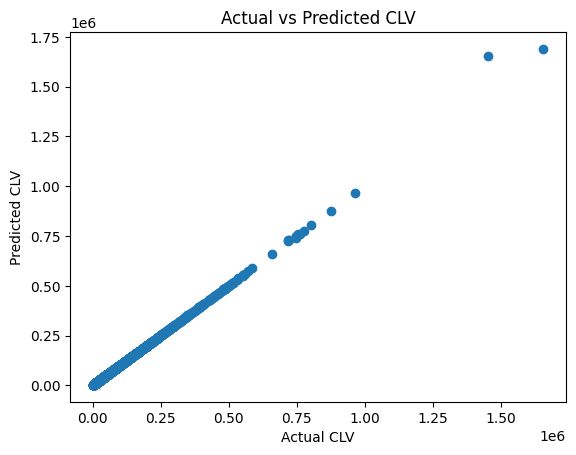

In [52]:
plt.scatter(y_test, predictions)

plt.xlabel("Actual CLV")
plt.ylabel("Predicted CLV")
plt.title("Actual vs Predicted CLV")

plt.show()

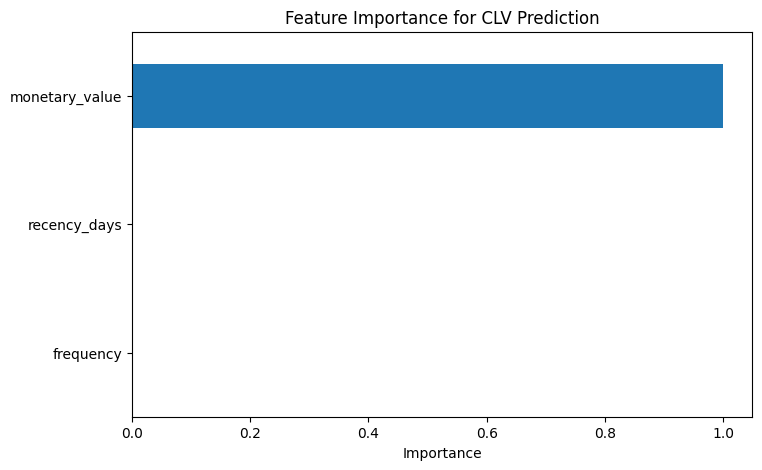

In [53]:
import pandas as pd

feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

feature_importance.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Feature Importance for CLV Prediction")
plt.xlabel("Importance")
plt.show()

In [56]:
import joblib

joblib.dump(model, "model.pkl")

['model.pkl']

In [55]:
rfm.to_csv("clv_dataset.csv", index=False)